In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/ml_group11/dataset"

train_2016_path = os.path.join(BASE_PATH, "train_2016_v2.csv")
train_2017_path = os.path.join(BASE_PATH, "train_2017.csv")
properties_2016_path = os.path.join(BASE_PATH, "properties_2016.csv")
properties_2017_path = os.path.join(BASE_PATH, "properties_2017.csv")

In [ ]:
def load_csv_if_exists(path, low_memory=False):
    if os.path.exists(path):
        print(f"Đang đọc: {path}")
        return pd.read_csv(path, low_memory=low_memory)
    print(f"Không tìm thấy: {path}")
    return None

train_2016 = load_csv_if_exists(train_2016_path, low_memory=False)
train_2017 = load_csv_if_exists(train_2017_path, low_memory=False)
properties_2016 = load_csv_if_exists(properties_2016_path, low_memory=False)
properties_2017 = load_csv_if_exists(properties_2017_path, low_memory=False)

Đang đọc: /content/drive/MyDrive/ml_group11/dataset/train_2016_v2.csv
Đang đọc: /content/drive/MyDrive/ml_group11/dataset/train_2017.csv
Đang đọc: /content/drive/MyDrive/ml_group11/dataset/properties_2016.csv
Đang đọc: /content/drive/MyDrive/ml_group11/dataset/properties_2017.csv


In [ ]:
merged_frames = []

if train_2016 is not None and properties_2016 is not None:
    df_2016 = train_2016.merge(properties_2016, how="left", on="parcelid")
    df_2016["data_year"] = 2016
    merged_frames.append(df_2016)
    print("2016 merged shape:", df_2016.shape)

if train_2017 is not None and properties_2017 is not None:
    df_2017 = train_2017.merge(properties_2017, how="left", on="parcelid")
    df_2017["data_year"] = 2017
    merged_frames.append(df_2017)
    print("2017 merged shape:", df_2017.shape)

if len(merged_frames) == 0:
    raise ValueError("Chưa có cặp file train + properties tương ứng để merge.")

df = pd.concat(merged_frames, axis=0, ignore_index=True)
print("Final merged shape:", df.shape)
df.head()

2016 merged shape: (90275, 61)
2017 merged shape: (77613, 61)
Final merged shape: (167888, 61)


,parcelid,logerror,transactiondate,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,data_year
0,11016594,0.0276,2016-01-01,1.0,NaN,NaN,2.0,3.0,NaN,4.0,2.0,NaN,NaN,1684.0,1684.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,34280990.0,-118488536.0,7528.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,LARS,6.037107e+07,12447.0,3101.0,31817.0,96370.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1959.0,NaN,NaN,122754.0,360170.0,2015.0,237416.0,6735.88,NaN,NaN,6.037107e+13,2016
1,14366692,-0.1684,2016-01-01,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,2263.0,2263.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,468.0,NaN,NaN,33668120.0,-117677556.0,3643.0,NaN,NaN,NaN,NaN,NaN,1,261.0,NaN,6.059052e+07,32380.0,1286.0,NaN,96962.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,2014.0,NaN,NaN,346458.0,585529.0,2015.0,239071.0,10153.02,NaN,NaN,NaN,2016
2,12098116,-0.0040,2016-01-01,1.0,NaN,NaN,3.0,2.0,NaN,4.0,3.0,NaN,NaN,2217.0,2217.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34136312.0,-118175032.0,11423.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,PSR6,6.037464e+07,47019.0,3101.0,275411.0,96293.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1940.0,NaN,NaN,61994.0,119906.0,2015.0,57912.0,11484.48,NaN,NaN,6.037464e+13,2016
3,12643413,0.0218,2016-01-02,1.0,NaN,NaN,2.0,2.0,NaN,4.0,2.0,NaN,NaN,839.0,839.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,33755800.0,-118309000.0,70859.0,NaN,NaN,NaN,NaN,NaN,010C,266.0,LAR3,6.037296e+07,12447.0,3101.0,54300.0,96222.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1987.0,NaN,NaN,171518.0,244880.0,2015.0,73362.0,3048.74,NaN,NaN,6.037296e+13,2016
4,14432541,-0.0050,2016-01-02,NaN,NaN,NaN,2.5,4.0,NaN,NaN,2.5,NaN,NaN,2283.0,2283.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,598.0,NaN,NaN,33485643.0,-117700234.0,6000.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059042e+07,17686.0,1286.0,NaN,96961.0,8.0,NaN,1.0,NaN,NaN,NaN,NaN,1981.0,2.0,NaN,169574.0,434551.0,2015.0,264977.0,5488.96,NaN,NaN,6.059042e+13,2016


In [ ]:
print("Dataset shape:", df.shape)
print("\nNumber of columns:", len(df.columns))
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes.value_counts())

print("\nDuplicate row rate:", round(df.duplicated().mean() * 100, 4), "%")

Dataset shape: (167888, 61)

Number of columns: 61

First 5 rows:


,parcelid,logerror,transactiondate,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,data_year
0,11016594,0.0276,2016-01-01,1.0,NaN,NaN,2.0,3.0,NaN,4.0,2.0,NaN,NaN,1684.0,1684.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,34280990.0,-118488536.0,7528.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,LARS,6.037107e+07,12447.0,3101.0,31817.0,96370.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1959.0,NaN,NaN,122754.0,360170.0,2015.0,237416.0,6735.88,NaN,NaN,6.037107e+13,2016
1,14366692,-0.1684,2016-01-01,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,2263.0,2263.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,468.0,NaN,NaN,33668120.0,-117677556.0,3643.0,NaN,NaN,NaN,NaN,NaN,1,261.0,NaN,6.059052e+07,32380.0,1286.0,NaN,96962.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,2014.0,NaN,NaN,346458.0,585529.0,2015.0,239071.0,10153.02,NaN,NaN,NaN,2016
2,12098116,-0.0040,2016-01-01,1.0,NaN,NaN,3.0,2.0,NaN,4.0,3.0,NaN,NaN,2217.0,2217.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34136312.0,-118175032.0,11423.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,PSR6,6.037464e+07,47019.0,3101.0,275411.0,96293.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1940.0,NaN,NaN,61994.0,119906.0,2015.0,57912.0,11484.48,NaN,NaN,6.037464e+13,2016
3,12643413,0.0218,2016-01-02,1.0,NaN,NaN,2.0,2.0,NaN,4.0,2.0,NaN,NaN,839.0,839.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,33755800.0,-118309000.0,70859.0,NaN,NaN,NaN,NaN,NaN,010C,266.0,LAR3,6.037296e+07,12447.0,3101.0,54300.0,96222.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1987.0,NaN,NaN,171518.0,244880.0,2015.0,73362.0,3048.74,NaN,NaN,6.037296e+13,2016
4,14432541,-0.0050,2016-01-02,NaN,NaN,NaN,2.5,4.0,NaN,NaN,2.5,NaN,NaN,2283.0,2283.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,598.0,NaN,NaN,33485643.0,-117700234.0,6000.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059042e+07,17686.0,1286.0,NaN,96961.0,8.0,NaN,1.0,NaN,NaN,NaN,NaN,1981.0,2.0,NaN,169574.0,434551.0,2015.0,264977.0,5488.96,NaN,NaN,6.059042e+13,2016



Data types:


,count
float64,53
object,6
int64,2



Duplicate row rate: 0.0 %


In [ ]:
# Target variable summary
target_col = "logerror"
assert target_col in df.columns, "Column 'logerror' not found."

print(df[target_col].describe())

count    167888.000000
mean          0.013906
std           0.165706
min          -4.655420
25%          -0.025300
50%           0.006000
75%           0.039200
max           5.262999
Name: logerror, dtype: float64


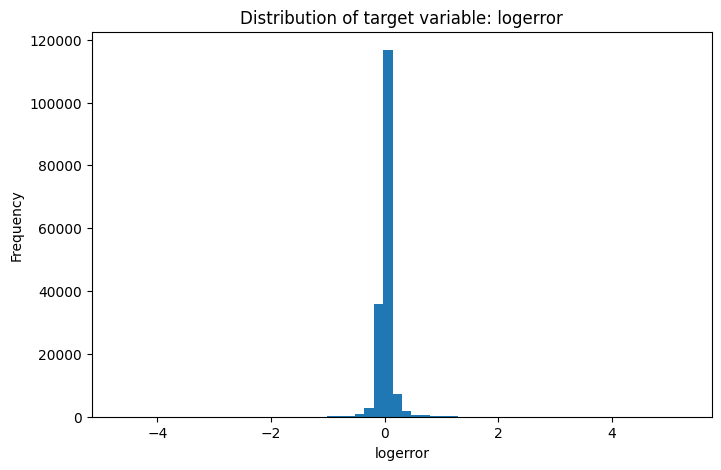

In [ ]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
plt.hist(df[target_col].dropna(), bins=60)
plt.title("Distribution of target variable: logerror")
plt.xlabel("logerror")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Missing values
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100)

missing_summary = (
    pd.DataFrame({
        "column": df.columns,
        "missing_count": missing_count.values,
        "missing_pct": missing_pct.values,
        "dtype": df.dtypes.astype(str).values,
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
    })
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

display(missing_summary.head(30))

,column,missing_count,missing_pct,dtype,n_unique
0,buildingclasstypeid,167857,99.981535,float64,2
1,finishedsquarefeet13,167813,99.955327,float64,17
2,basementsqft,167795,99.944606,float64,78
3,storytypeid,167795,99.944606,float64,1
4,yardbuildingsqft26,167723,99.901720,float64,112
5,fireplaceflag,167494,99.765320,object,1
6,architecturalstyletypeid,167420,99.721243,float64,6
7,typeconstructiontypeid,167366,99.689078,float64,4
8,finishedsquarefeet6,167081,99.519322,float64,649
9,decktypeid,166616,99.242352,float64,1


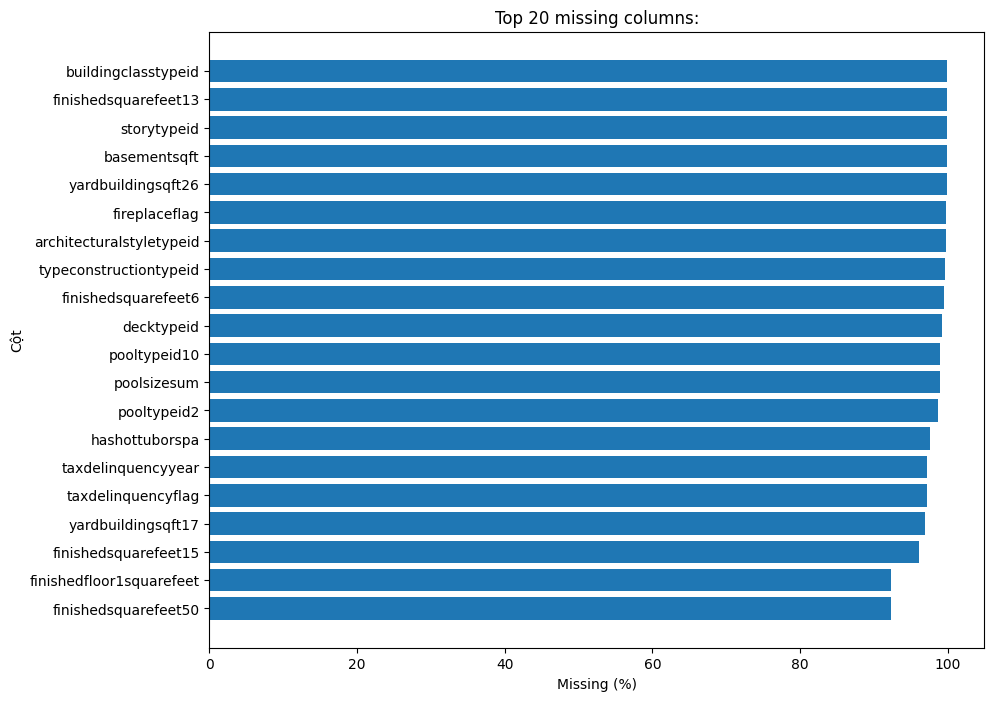

In [ ]:
# top 20 missing value
top_missing = missing_summary.head(20).sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.title("Top 20 missing columns:")
plt.xlabel("Missing (%)")
plt.ylabel("Cột")
plt.show()

In [ ]:
# Numeric and categorical column breakdown
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

display(df[numeric_cols].describe().T.head(20))

Numeric columns: 55
Categorical columns: 6


,count,mean,std,min,25%,50%,75%,max
parcelid,167888.0,1.299536e+07,3.016071e+06,1.071174e+07,1.154899e+07,1.254060e+07,1.421930e+07,1.676893e+08
logerror,167888.0,1.390631e-02,1.657059e-01,-4.655420e+00,-2.530000e-02,6.000000e-03,3.920000e-02,5.262999e+00
airconditioningtypeid,53788.0,1.814345e+00,2.970239e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.300000e+01
architecturalstyletypeid,468.0,7.299145e+00,2.719633e+00,2.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,2.100000e+01
basementsqft,93.0,6.953763e+02,5.839521e+02,3.800000e+01,2.800000e+02,5.880000e+02,8.190000e+02,3.560000e+03
bathroomcnt,167854.0,2.288265e+00,1.000835e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01
bedroomcnt,167854.0,3.041739e+00,1.149134e+00,0.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
buildingclasstypeid,31.0,3.967742e+00,1.796053e-01,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
buildingqualitytypeid,107173.0,6.015461e+00,1.882799e+00,1.000000e+00,4.000000e+00,7.000000e+00,7.000000e+00,1.200000e+01
calculatedbathnbr,166056.0,2.312542e+00,9.778076e-01,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01


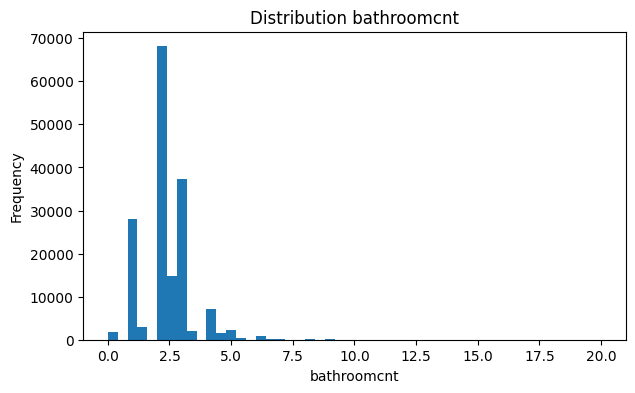

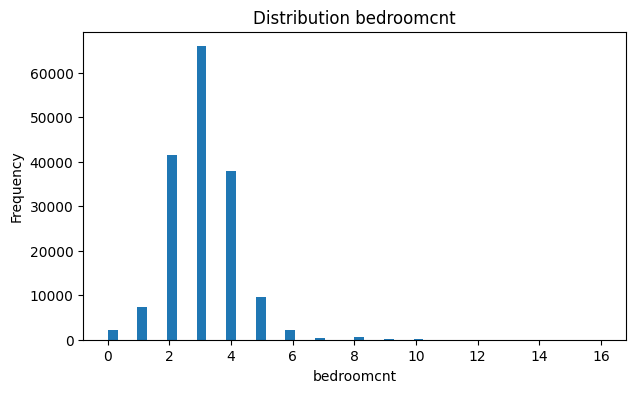

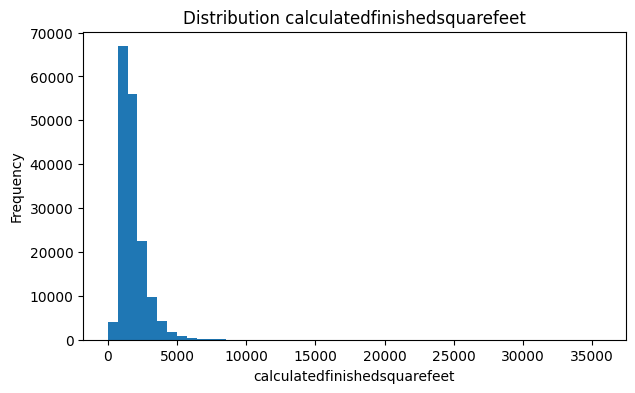

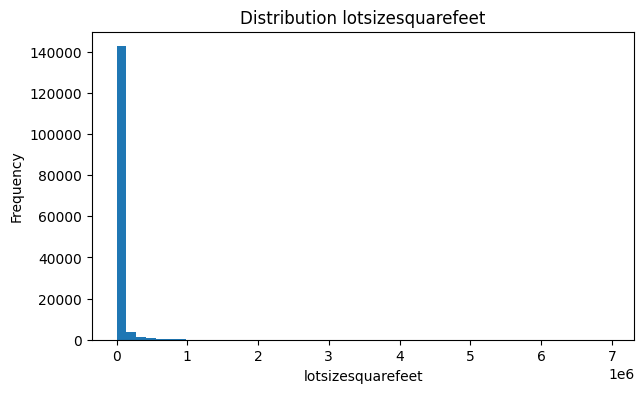

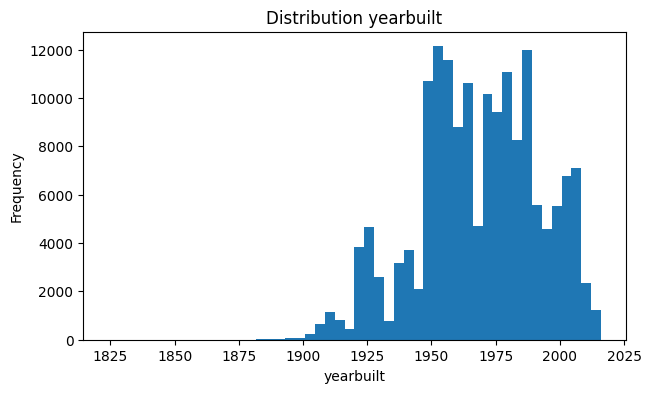

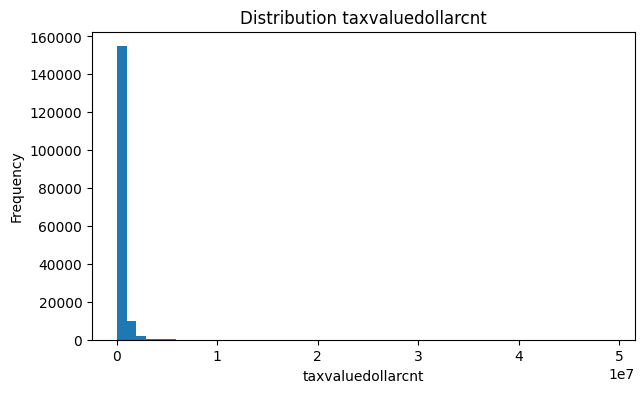

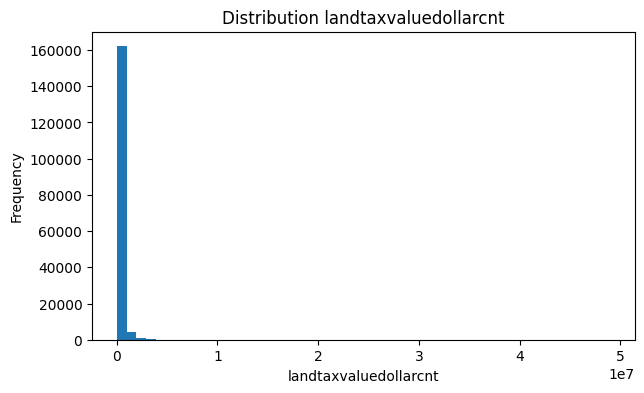

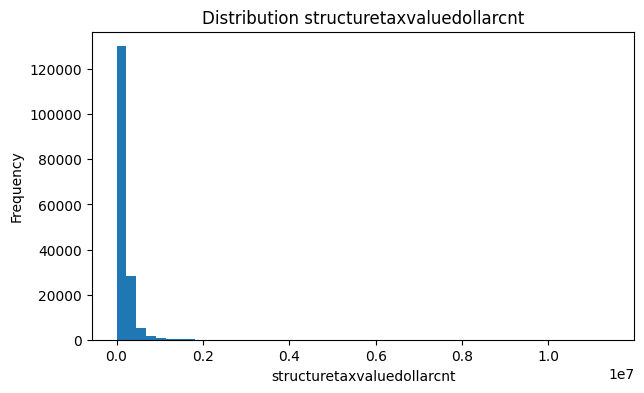

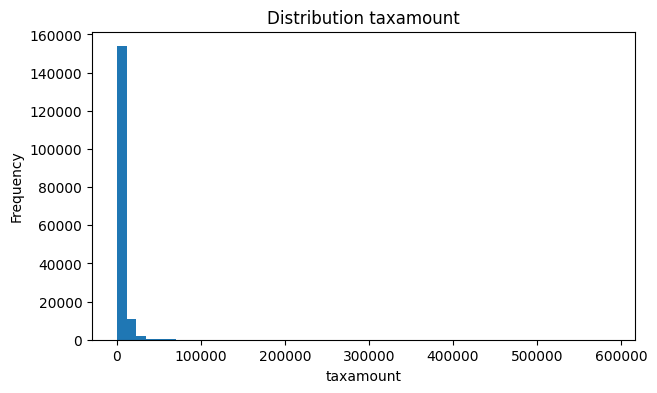

In [ ]:
# Xem phân phối của một số biến số quan trọng nếu tồn tại
candidate_cols = [
    "bathroomcnt",
    "bedroomcnt",
    "calculatedfinishedsquarefeet",
    "lotsizesquarefeet",
    "yearbuilt",
    "taxvaluedollarcnt",
    "landtaxvaluedollarcnt",
    "structuretaxvaluedollarcnt",
    "taxamount"
]

available_candidates = [c for c in candidate_cols if c in df.columns]

for col in available_candidates:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
# Correlation with target variable
corr_target = (
    df[numeric_cols]
    .corr(numeric_only=True)[target_col]
    .dropna()
    .sort_values(ascending=False)
)

print("Top positive correlations with logerror:")
display(corr_target.head(15))

print("Top negative correlations with logerror:")
display(corr_target.tail(15))

Top positive correlations with logerror:


,logerror
logerror,1.000000
basementsqft,0.324681
buildingclasstypeid,0.125978
yardbuildingsqft26,0.054912
finishedsquarefeet6,0.049720
finishedsquarefeet12,0.043977
calculatedfinishedsquarefeet,0.039710
garagetotalsqft,0.029616
calculatedbathnbr,0.029432
bedroomcnt,0.028513


Top negative correlations with logerror:


,logerror
landtaxvaluedollarcnt,-0.000759
propertylandusetypeid,-0.002179
taxamount,-0.002186
latitude,-0.002931
regionidzip,-0.003975
regionidneighborhood,-0.005500
architecturalstyletypeid,-0.006321
regionidcounty,-0.007566
buildingqualitytypeid,-0.007896
finishedsquarefeet15,-0.008050


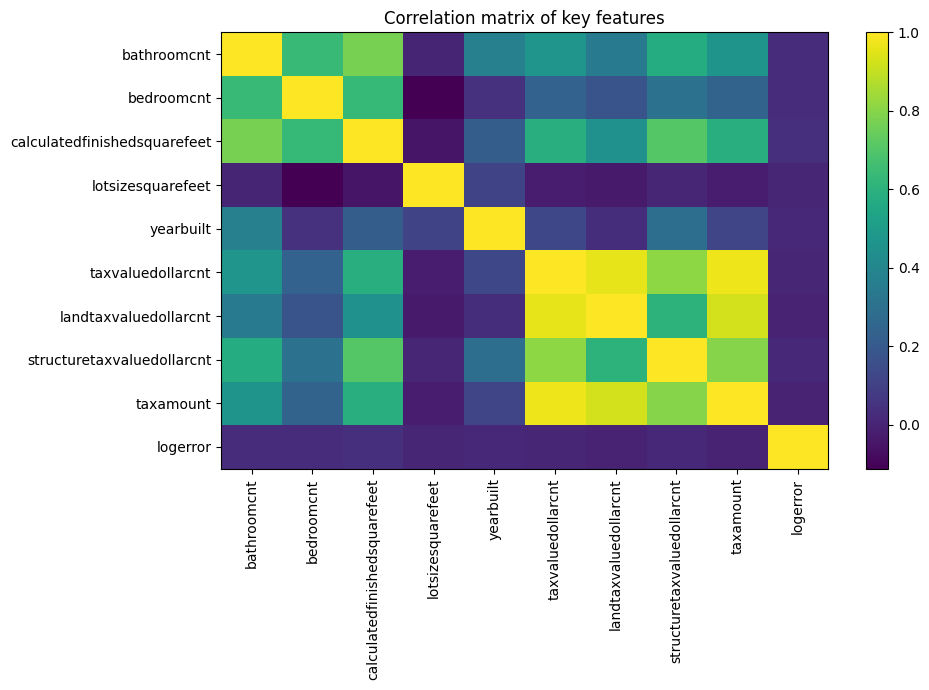

In [ ]:
# Correlation matrix heatmap for key features
corr_cols = [c for c in available_candidates if c in df.columns] + [target_col]
corr_cols = list(dict.fromkeys([c for c in corr_cols if c in df.columns]))

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    im = plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(im)
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.title("Correlation matrix of key features")
    plt.tight_layout()
    plt.show()

In [ ]:
# Outlier detection using IQR
def count_outliers_iqr(series):
    s = series.dropna()
    if len(s) == 0:
        return 0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

outlier_rows = []
for col in numeric_cols:
    if col == target_col:
        continue
    try:
        outlier_rows.append({
            "column": col,
            "outlier_count": count_outliers_iqr(df[col]),
            "non_null_count": int(df[col].notna().sum())
        })
    except Exception:
        pass

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary["outlier_pct_among_non_null"] = (
    outlier_summary["outlier_count"] / outlier_summary["non_null_count"] * 100
)
outlier_summary = outlier_summary.sort_values(
    "outlier_pct_among_non_null", ascending=False
).reset_index(drop=True)

display(outlier_summary.head(20))

,column,outlier_count,non_null_count,outlier_pct_among_non_null
0,garagecarcnt,14877,55457,26.826190
1,roomcnt,38188,167854,22.750724
2,lotsizesquarefeet,24441,149446,16.354402
3,architecturalstyletypeid,74,468,15.811966
4,fireplacecnt,2713,17896,15.159812
5,yardbuildingsqft26,15,165,9.090909
6,rawcensustractandblock,13448,167854,8.011724
7,fips,13448,167854,8.011724
8,finishedsquarefeet13,6,75,8.000000
9,censustractandblock,13341,167002,7.988527


In [ ]:
df_clean = df.copy()

# 1. Remove duplicate
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Đã xóa {before - after} dòng trùng lặp")

# 2. extract time features
if "transactiondate" in df_clean.columns:
    df_clean["transactiondate"] = pd.to_datetime(df_clean["transactiondate"], errors="coerce")
    df_clean["transaction_year"] = df_clean["transactiondate"].dt.year
    df_clean["transaction_month"] = df_clean["transactiondate"].dt.month
    df_clean["transaction_quarter"] = df_clean["transactiondate"].dt.quarter
    print("Đã tạo thêm các biến thời gian từ transactiondate")


Đã xóa 0 dòng trùng lặp
Đã tạo thêm các biến thời gian từ transactiondate


In [ ]:
# 3. Drop columns with >98% missing values
MISSING_THRESHOLD = 0.98

missing_ratio = df_clean.isna().mean()
cols_to_drop_missing = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()

cols_to_drop_missing = [c for c in cols_to_drop_missing if c != "logerror"]

df_clean = df_clean.drop(columns=cols_to_drop_missing)
print("Numver of dropped columns:", len(cols_to_drop_missing))
print("Examples:", cols_to_drop_missing[:15])


Numver of dropped columns: 13
Examples: ['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedsquarefeet13', 'finishedsquarefeet6', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft26', 'fireplaceflag']


In [ ]:
# 4. Drop columns with only one value
nunique = df_clean.nunique(dropna=False)
single_value_cols = nunique[nunique <= 1].index.tolist()
single_value_cols = [c for c in single_value_cols if c != "logerror"]

df_clean = df_clean.drop(columns=single_value_cols)
print("Số cột bị xóa do chỉ có 1 giá trị:", len(single_value_cols))
print("Ví dụ:", single_value_cols[:15])


Số cột bị xóa do chỉ có 1 giá trị: 0
Ví dụ: []


In [ ]:
# 5.  Separate target (y) and features (X); drop raw date column
target = "logerror"
id_cols = [c for c in ["parcelid"] if c in df_clean.columns]

y = df_clean[target].copy()
X = df_clean.drop(columns=[target], errors="ignore").copy()

if "transactiondate" in X.columns:
    X = X.drop(columns=["transactiondate"])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (167888, 49)
y shape: (167888,)


In [ ]:
# 6. Seperate train/test
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (134310, 49)
X_test: (33578, 49)
y_train: (134310,)
y_test: (33578,)


In [ ]:
# 7. Indentiy column type from training set
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 45
Categorical features: 4


In [ ]:
# 8. Winsorize numeric outliers using 1st-99th percentile bounds from train
# Not apply for ID columns
numeric_to_clip = [c for c in numeric_features if c not in id_cols]

X_train_clipped = X_train.copy()
X_test_clipped = X_test.copy()
clip_bounds = {}

for col in numeric_to_clip:
    s_train = X_train_clipped[col]
    if s_train.notna().sum() == 0:
        continue
    lower = s_train.quantile(0.01)
    upper = s_train.quantile(0.99)
    clip_bounds[col] = (lower, upper)
    X_train_clipped[col] = s_train.clip(lower=lower, upper=upper)
    X_test_clipped[col] = X_test_clipped[col].clip(lower=lower, upper=upper)

X_train = X_train_clipped
X_test = X_test_clipped
print("Finish clipping outlier based on quantile 1% - 99% for training set")


Finish clipping outlier based on quantile 1% - 99% for training set


In [ ]:
# 9. Split categorical into low-cardinality and high-cardinality on training set
low_cardinality_cols = []
high_cardinality_cols = []

for col in categorical_features:
    n_uni = X_train[col].nunique(dropna=True)
    if n_uni <= 20:
        low_cardinality_cols.append(col)
    else:
        high_cardinality_cols.append(col)

print("Low-cardinality categorical:", len(low_cardinality_cols))
print("High-cardinality categorical:", len(high_cardinality_cols))
print("Ví dụ high-cardinality:", high_cardinality_cols[:10])


Low-cardinality categorical: 2
High-cardinality categorical: 2
Ví dụ high-cardinality: ['propertycountylandusecode', 'propertyzoningdesc']


In [ ]:
# 10. Frequency encoding for categorical wwith high cardinality
# Fit map on train, appl into test
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
freq_encoding_maps = {}

for col in high_cardinality_cols:
    freq_map = X_train_fe[col].value_counts(normalize=True, dropna=False)
    freq_encoding_maps[col] = freq_map
    X_train_fe[col + "_freq"] = X_train_fe[col].map(freq_map)
    X_test_fe[col + "_freq"] = X_test_fe[col].map(freq_map).fillna(0)

# After encoding frequency, we remove columns with high-cardinality
X_train_fe = X_train_fe.drop(columns=high_cardinality_cols)
X_test_fe = X_test_fe.drop(columns=high_cardinality_cols)


In [ ]:
# 11. Update column type lists after frequency encoding
numeric_features_final = X_train_fe.select_dtypes(include=["number"]).columns.tolist()
categorical_features_final = X_train_fe.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric final:", len(numeric_features_final))
print("Categorical final:", len(categorical_features_final))


Numeric final: 47
Categorical final: 2


In [ ]:
# 12. Pipeline preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_final),
        ("cat", categorical_transformer, categorical_features_final)
    ],
    remainder="drop"
)

In [ ]:
# 13. Fit preprocessor on train, transform on both train and test
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train_fe.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_fe.index)

train_final_df = pd.concat([X_train_processed_df, y_train], axis=1)
test_final_df = pd.concat([X_test_processed_df, y_test], axis=1)

print("Train sau tiền xử lý:", train_final_df.shape)
print("Test sau tiền xử lý:", test_final_df.shape)
display(train_final_df.head())

Train sau tiền xử lý: (134310, 50)
Test sau tiền xử lý: (33578, 50)


,num__parcelid,num__airconditioningtypeid,num__bathroomcnt,num__bedroomcnt,num__buildingqualitytypeid,num__calculatedbathnbr,num__finishedfloor1squarefeet,num__calculatedfinishedsquarefeet,num__finishedsquarefeet12,num__finishedsquarefeet15,num__finishedsquarefeet50,num__fips,num__fireplacecnt,num__fullbathcnt,num__garagecarcnt,num__garagetotalsqft,num__heatingorsystemtypeid,num__latitude,num__longitude,num__lotsizesquarefeet,num__poolcnt,num__pooltypeid7,num__propertylandusetypeid,num__rawcensustractandblock,num__regionidcity,num__regionidcounty,num__regionidneighborhood,num__regionidzip,num__roomcnt,num__threequarterbathnbr,num__unitcnt,num__yardbuildingsqft17,num__yearbuilt,num__numberofstories,num__structuretaxvaluedollarcnt,num__taxvaluedollarcnt,num__assessmentyear,num__landtaxvaluedollarcnt,num__taxamount,num__taxdelinquencyyear,num__censustractandblock,num__data_year,num__transaction_year,num__transaction_month,num__transaction_quarter,num__propertycountylandusecode_freq,num__propertyzoningdesc_freq,cat__hashottuborspa_True,cat__taxdelinquencyflag_Y,logerror
49526,-0.313000,-0.15184,-0.291060,-1.865773,-3.414695,-0.323481,-0.04429,-0.292891,-0.261155,-0.050817,-0.04688,-0.572275,-0.120835,-0.254421,0.193854,0.196716,-0.398711,0.318434,-0.514094,-0.243256,0.0,0.0,1.025757,-0.557690,0.317923,0.710947,-0.254269,-1.192297,-0.525659,0.0,-0.186826,-0.041907,0.523687,-0.313236,0.390377,0.618017,-0.925345,0.671148,0.598100,0.019583,-0.555525,-0.925664,-0.925664,0.195112,-0.183584,-0.474956,-0.813026,1.0,1.0,-0.458900
132114,-0.688723,-0.15184,-0.291060,-0.944709,1.039088,-0.323481,-0.04429,-0.010474,0.033713,-0.050817,-0.04688,-0.572275,-0.120835,-0.254421,0.193854,0.196716,-0.398711,0.564542,-0.675927,-0.239546,0.0,0.0,-0.214955,-0.585449,-0.454360,0.710947,-1.088958,-0.285092,-0.525659,0.0,-0.186826,-0.041907,-0.580521,-0.313236,-0.311857,-0.021732,1.080677,0.141768,-0.073505,0.019583,-0.583360,1.080305,1.080305,-0.183056,-0.183584,1.290237,-0.300401,1.0,1.0,0.000283
92695,-0.389568,-0.15184,-0.291060,-0.944709,0.402833,-0.323481,-0.04429,-0.909502,-0.904951,-0.050817,-0.04688,-0.572275,-0.120835,-0.254421,0.193854,0.196716,-0.398711,0.172658,-0.179648,0.755186,0.0,0.0,1.025757,-0.581546,-0.454360,0.710947,1.174748,-1.318432,-0.525659,0.0,-0.186826,-0.041907,1.585426,-0.313236,1.329081,0.301341,1.080677,-0.285729,0.245235,0.019583,-0.579447,1.080305,1.080305,-1.695727,-1.325651,-0.474956,-0.828593,1.0,1.0,0.008522
165526,-0.562374,-0.15184,-0.291060,-0.023646,1.039088,-0.323481,-0.04429,0.389617,0.451443,-0.050817,-0.04688,-0.572275,-0.120835,-0.254421,0.193854,0.196716,-0.398711,1.848623,0.105108,1.034245,0.0,0.0,-0.214955,-0.547481,-0.363558,0.710947,-0.254269,1.834954,-0.525659,0.0,-0.186826,-0.041907,1.160731,-0.313236,0.244283,-0.316997,1.080677,-0.578044,-0.139267,0.019583,-0.545287,1.080305,1.080305,1.329616,0.958482,1.290237,-0.809169,1.0,1.0,-0.009274
94935,-0.602759,-0.15184,0.763679,0.897418,1.039088,0.765068,-0.04429,0.270766,0.327353,-0.050817,-0.04688,-0.572275,-0.120835,0.867568,0.193854,0.196716,5.559814,1.686092,-1.009183,-0.306071,0.0,0.0,-0.214955,-0.547029,-0.180217,0.710947,-0.254269,-0.399099,-0.525659,0.0,-0.186826,-0.041907,1.840244,-0.313236,0.843093,-0.027486,1.080677,-0.490280,0.709832,0.019583,-0.544834,1.080305,1.080305,-1.695727,-1.325651,1.290237,-0.811465,1.0,1.0,0.034342


In [ ]:
# 14. Check for missing after preprocessing
print("Tổng số missing trên train sau xử lý:", int(train_final_df.isna().sum().sum()))
print("Tổng số missing trên test sau xử lý:", int(test_final_df.isna().sum().sum()))

Tổng số missing trên train sau xử lý: 0
Tổng số missing trên test sau xử lý: 0


In [ ]:
# Default RF:
baseline_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
baseline_rf.fit(X_train_processed_df, y_train)
print("Baseline Random Forest trained.")

Baseline Random Forest trained.


In [ ]:
# Evaluate baseline on the held-out test set
y_pred_baseline = baseline_rf.predict(X_test_processed_df)

baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)

print(" BASELINE RANDOM FOREST")
print(f"MAE: {baseline_mae:.6f}")
print(f"RMSE: {baseline_rmse:.6f}")
print(f"R^2: {baseline_r2:.6f}")

 BASELINE RANDOM FOREST
MAE: 0.075422
RMSE: 0.170595
R^2: -0.014465


In [ ]:
def objective(trial):
    """Optuna objective"""
    params = {
        "n_estimators":trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth":trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
    model = RandomForestRegressor(**params)
    cv_scores = cross_val_score(
        model,
        X_train_processed_df,
        y_train,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    return -cv_scores.mean()

In [ ]:
# Run the Optuna study
N_TRIALS = 30

study = optuna.create_study(direction="minimize", study_name="rf_zillow")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\nOptuna finished {N_TRIALS} trials.")
print(f"Best trial: #{study.best_trial.number}")
print(f"Best CV MAE: {study.best_value:.6f}")
print("\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f" {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Optuna finished 30 trials.
Best trial: #20
Best CV MAE: 0.068840

Best hyperparameters:
 n_estimators: 300
 max_depth: 8
 min_samples_split: 10
 min_samples_leaf: 9
 max_features: log2
 bootstrap: True


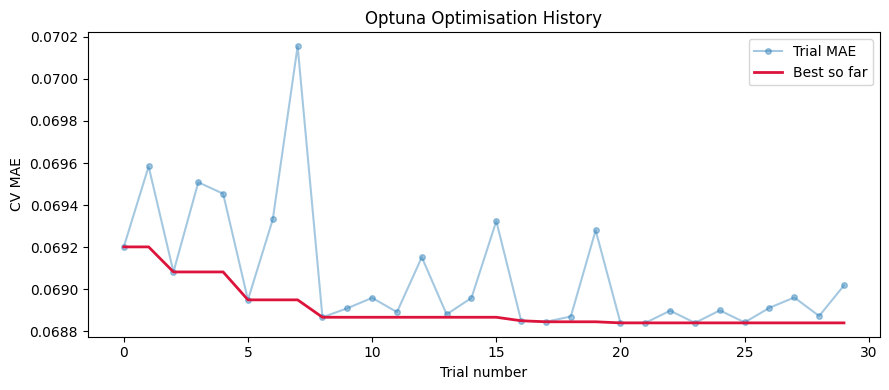

In [ ]:
# Visualise the optimisation history
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()

plt.figure(figsize=(9, 4))
plt.plot(trial_values, alpha=0.4, label="Trial MAE", marker="o", markersize=4)
plt.plot(best_so_far, lw=2, label="Best so far", color="crimson")
plt.title("Optuna Optimisation History")
plt.xlabel("Trial number")
plt.ylabel("CV MAE")
plt.legend()
plt.tight_layout()
plt.show()

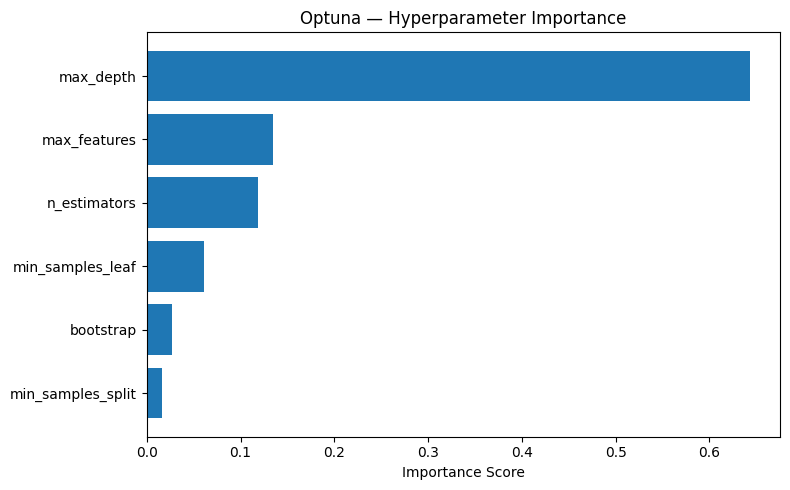

In [ ]:
# Visualise which hyperparameters mattered most
param_importance = optuna.importance.get_param_importances(study)
param_names = list(param_importance.keys())
param_scores = list(param_importance.values())

plt.figure(figsize=(8, 5))
plt.barh(param_names[::-1], param_scores[::-1])
plt.title("Optuna — Hyperparameter Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# Retrain on the full training set using Optuna's best parameters
best_params = study.best_params.copy()
best_params["random_state"] = RANDOM_STATE
best_params["n_jobs"] = -1

final_rf = RandomForestRegressor(**best_params)
final_rf.fit(X_train_processed_df, y_train)

print("Final model trained:").
for k, v in best_params.items():
    print(f" {k}: {v}")

Final model trained:
 n_estimators: 300
 max_depth: 8
 min_samples_split: 10
 min_samples_leaf: 9
 max_features: log2
 bootstrap: True
 random_state: 42
 n_jobs: -1


In [ ]:
# Evaluate the final model on the test set
y_pred_final = final_rf.predict(X_test_processed_df)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print(" FINAL MODEL (Optuna-tuned RF)")
print(f"MAE: {final_mae:.6f}")
print(f"RMSE: {final_rmse:.6f}")
print(f"R^2: {final_r2:.6f}")

 FINAL MODEL (Optuna-tuned RF)
MAE: 0.069749
RMSE: 0.168521
R^2: 0.010057


In [ ]:
# Comparison: Baseline vs Tuned
comparison = pd.DataFrame({
    "Model": ["Baseline RF (default)", "Optuna-tuned RF"],
    "MAE": [round(baseline_mae, 6), round(final_mae, 6)],
    "RMSE": [round(baseline_rmse, 6), round(final_rmse, 6)],
    "R²": [round(baseline_r2, 6), round(final_r2, 6)]
})

display(comparison)

# Print delta
mae_delta = (baseline_mae  - final_mae)  / baseline_mae  * 100
rmse_delta = (baseline_rmse - final_rmse) / baseline_rmse * 100
print(f"\nMAE  improvement over baseline: {mae_delta:+.2f}%")
print(f"RMSE improvement over baseline: {rmse_delta:+.2f}%")

,Model,MAE,RMSE,R²
0,Baseline RF (default),0.075422,0.170595,-0.014465
1,Optuna-tuned RF,0.069749,0.168521,0.010057



MAE  improvement over baseline: +7.52%
RMSE improvement over baseline: +1.22%
